In [11]:
%matplotlib widget

In [12]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [13]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA.csv")
SNR_HB = pd.read_csv("SNR_HB.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1.csv") 

In [14]:
SNR_OIII_2

,Unnamed: 0,SNR,Signal,Noise
0,Spettro_1,NaN,NaN,NaN
1,Spettro_2,NaN,NaN,NaN
2,Spettro_3,NaN,NaN,NaN
3,Spettro_4,7.630,0.393,0.051
4,Spettro_5,6.912,0.450,0.065
5,Spettro_6,21.979,1.530,0.070
6,Spettro_7,90.625,7.897,0.087
7,Spettro_8,105.409,14.414,0.137
8,Spettro_9,41.830,4.008,0.096
9,Spettro_10,8.569,0.848,0.099


In [15]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    else: return False 

Nan: 1
nan nan nan nan nan
Nan: 2
nan nan nan nan nan
Nan: 3
nan nan nan nan nan
Nan: 4
28.782 3.206 4.636 0.358 7.63
Nan: 16
20.653 2.695 9.548 1.381 3.992
Nan: 17
17.148 2.219 7.585 2.307 0.743
Nan: 18
7.36 -1.161 3.755 2.382 0.589
Nan: 19
nan nan nan nan nan
Nan: 20
nan nan nan nan nan


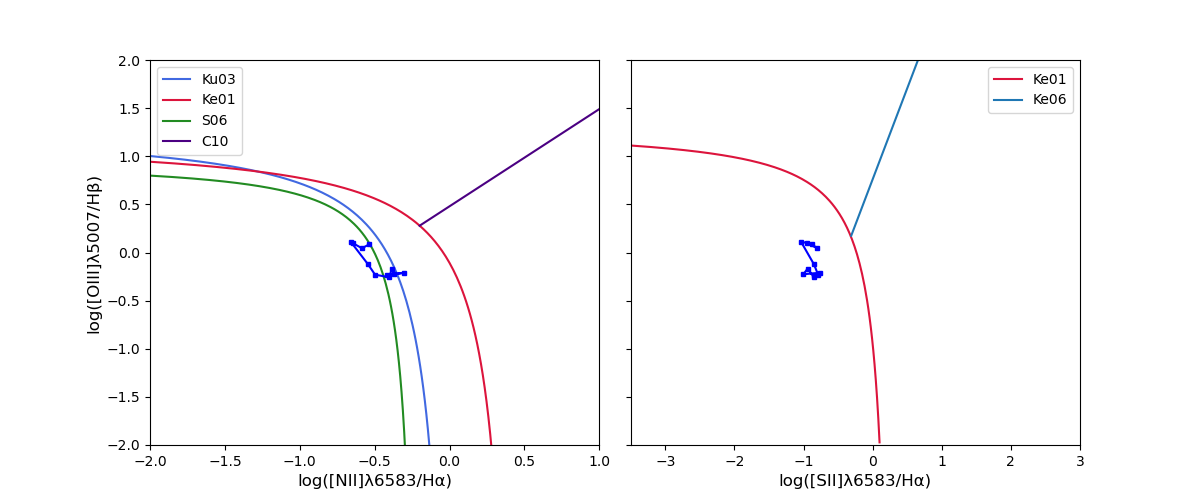

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
    
ax[0].plot(NII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].plot(NII_HA[0], OIII_HB[0], color='red', marker= 's', linestyle='-', markersize = 3) 
ax[0].plot(NII_HA[-1], OIII_HB[-1], color='orange', marker= 's', linestyle='-', markersize = 3) 
ax[1].plot(SII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[0], OIII_HB[0], color='green', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[-1], OIII_HB[-1], color='purple', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-3.5, 3)
ax[1].set_ylim(-2, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
#plt.savefig('BPT_grad.png', bbox_inches='tight')

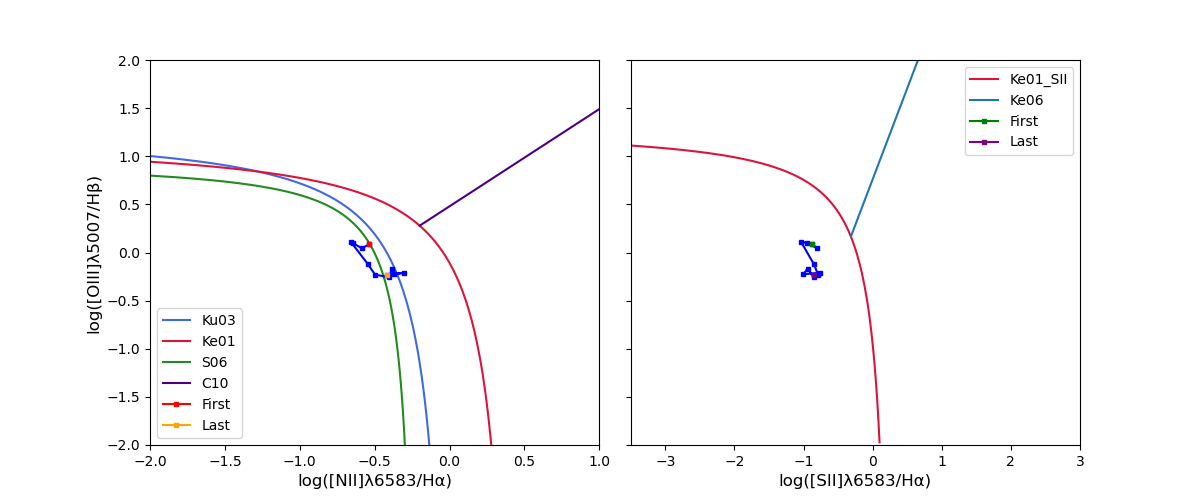

In [17]:
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax2[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax2[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax2[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax2[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')

x = np.linspace(-3.5, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax2[1].plot(x, Ke01_SII(x), label = 'Ke01_SII', color = 'crimson')
ax2[1].plot(x1, Ke06(x1), label = 'Ke06')

ax2[0].plot(NII_HA_ok, OIII_HB_ok, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax2[0].plot(NII_HA_ok[0], OIII_HB_ok[0], color='red', marker= 's', linestyle='-', markersize = 3, label ='First') 
ax2[0].plot(NII_HA_ok[-1], OIII_HB_ok[-1], color='orange', marker= 's', linestyle='-', markersize = 3, label ='Last') 
ax2[1].plot(SII_HA_ok, OIII_HB_ok, color='blue', marker= 's', linestyle='-', markersize = 3)
ax2[1].plot(SII_HA_ok[0], OIII_HB_ok[0], color='green', marker= 's', linestyle='-', markersize = 3,label ='First')
ax2[1].plot(SII_HA_ok[-1], OIII_HB_ok[-1], color='purple', marker= 's', linestyle='-', markersize = 3, label ='Last')

ax2[0].set_xlim(-2, 1)
ax2[0].set_ylim(-1.5, 2)
ax2[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax2[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax2[0].legend()

ax2[1].set_xlim(-3.5, 3)
ax2[1].set_ylim(-2, 2)
ax2[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax2[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')